#Code with the topic: ROC and AUC

#Description: This code aims to teach and explain the code structure of the topic: ROC and AUC, using a csv dataset.


#Technologies used:

#Pandas
#sklearn
#Python
#Visual Studio Code
#Jupyter Notebook

#Method used:

#Logistic Regression

#What problem do we want to solve

#to evaluate how well a binary classification model works

#How to use the code 

#This code is used to understand how ROC and AUC are structured, which is why it is composed of instructions in each line of code.

In [ ]:
#We call the libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve,roc_auc_score

In [ ]:
#We load the dataset with pandas
data = pd.read_csv("ROC_AUC.csv")

In [ ]:
#We see our data in a table
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     4 non-null      int64
 1   income  4 non-null      int64
 2   buys    4 non-null      int64
dtypes: int64(3)
memory usage: 228.0 bytes


In [5]:
data.describe()

,age,income,buys
count,4.00000,4.000000,4.00000
mean,30.50000,4250.000000,0.50000
std,8.42615,2217.355783,0.57735
min,22.00000,2000.000000,0.00000
25%,24.25000,2750.000000,0.00000
50%,30.00000,4000.000000,0.50000
75%,36.25000,5500.000000,1.00000
max,40.00000,7000.000000,1.00000


In [ ]:
#We use columns to avoid mistakes
data.columns

Index(['age', 'income', 'buys'], dtype='object')

In [ ]:
# We define adn separate X and Y
x = data.drop(columns=["buys"])
y = data["buys"]

In [ ]:
#We divided training and testing.
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
#We created the model and trained
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
#we get probabilities
y_scores = model.predict_proba(x_test)[:,1]

In [ ]:
#we calculate ROC
fpr, tpr, thresholds = roc_curve(y_test,y_scores)

c:\Users\Selene\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


In [ ]:
#We calculate AUC

auc = roc_auc_score(y_test,y_scores)
print(f"AUC: {auc:.3f}")

AUC: nan


c:\Users\Selene\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


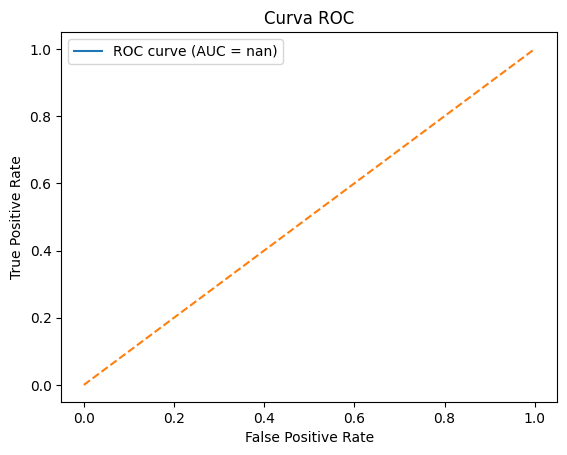

In [ ]:
#We graphed the ROC curve

plt.figure()
plt.plot(fpr, tpr, label = f"ROC curve (AUC = {auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()